# 🌐 Lanac opskrbe poluvodiča — analiza mreže (objedinjeni pregled)

**Projekt iz kolegija Analiza mreža — PMF-UNIST, 2025/2026**

Ovaj notebook **spaja cijeli projekt na jedno mjesto** i detaljno ga objašnjava
korak po korak. Pojedinačne, dublje analize ostaju u zasebnim notebookovima
(`01`–`08`); ovdje je cjelovita priča koju možeš proći od početka do kraja.

---

## O čemu se radi

Globalni lanac opskrbe poluvodiča (čipova) modeliramo kao **graf**: tvrtke,
zemlje, proizvodi i tvornice su **čvorovi**, a odnosi među njima (tko koga
opskrbljuje, tko što proizvodi, gdje se nalazi…) su **veze**. Nad tim grafom
provodimo analizu mreže koja pokriva sve glavne teme kolegija.

## Hipoteza koju testiramo

> *„Lanac opskrbe poluvodiča je ultra-krhka scale-free mreža u kojoj uklanjanje
> 3–5 čvorova-čvorišta (TSMC, ASML, Shin-Etsu, Air Products i jedan veliki ARM
> licencar) uzrokuje katastrofalnu fragmentaciju velike povezane komponente,
> modelirajući stvarnu krizu čipova 2020.–2022.“*

Kroz notebook ćemo **provjeriti svaki dio te tvrdnje** i na kraju donijeti
pošten zaključak — uključujući i dijelove gdje podaci hipotezu **opovrgavaju**.

## Sadržaj
1. Postavljanje i učitavanje grafa
2. Što je u grafu? (struktura podataka i shema)
3. Projekcija SUPPLIES — objekt nad kojim radimo analizu
4. **L2** Osnovna svojstva grafa
5. **L3** Centralnost — tko su uska grla?
6. **L4** Povezanost — artikulacijske točke i mostovi
7. **L5** Zajednice — Louvain, tier vs geografija
8. **L6/L7** Slučajni model (ER) i small-world svojstvo
9. **L8** Distribucija stupnjeva — je li mreža scale-free?
10. **L9** Otpornost — ciljani vs slučajni napad
11. **Proširenje** Koncentracija i težinska (kapacitetom-ponderirana) otpornost
12. **Null-model testiranje** — jesu li nalazi statistički značajni?
13. Sinteza i konačni zaključak

## 0. Uvod u temu — kako nastaje čip i tko ga radi

Prije analize mreže, kratko o **samoj temi**, jer bez nje brojke nemaju smisla.

### Što je uopće lanac opskrbe poluvodiča?

Moderni **čip** (procesor, memorija, senzor…) je možda **najsloženiji proizvod
koji čovječanstvo radi**. Niti jedna tvrtka, pa ni jedna država, ne može sama
napraviti napredni čip. Umjesto toga, stotine visoko specijaliziranih tvrtki iz
desetak zemalja surađuju u dugom nizu koraka — i upravo taj **niz međuovisnosti
je „lanac opskrbe“** koji modeliramo kao mrežu.

Tipičan napredni čip „prijeđe svijet“ više puta prije nego što je gotov: dizajn
u SAD-u/UK, oprema iz Nizozemske, materijali iz Japana, proizvodnja na Tajvanu,
pakiranje u Kini — i tek onda u uređaj. Zbog te specijalizacije i geografske
koncentracije, lanac je **moćan, ali i ranjiv** (kriza čipova 2020.–2022.).

### Tko su igrači? (slojevi / „tierovi“)

Lanac nije lista jednakih tvrtki — svaka ima usku ulogu:

- **EDA i IP** *(omogućivači dizajna)* — softver za projektiranje čipova (EDA:
  Synopsys, Cadence) i gotovi „nacrti“ blokova (IP: ARM, SiFive). Bez njih se
  čip ne može ni nacrtati.
- **Materijali i kemikalije** — silicijske pločice (wafer: Shin-Etsu, SUMCO),
  fotorezist (JSR, Tokyo Ohka), specijalni plinovi (Air Liquide, Linde),
  podloge/ABF film (Ajinomoto). Sirovine od kojih čip fizički nastaje.
- **Oprema (alati)** — golemi strojevi za proizvodnju: litografija (**ASML** —
  jedini na svijetu za EUV!), jetkanje i depozicija (Applied Materials, Lam,
  Tokyo Electron), mjerenje (KLA).
- **Ljevaonice (foundry), IDM i fabless** — ovdje se čip *radi*:
  - **Foundry** = proizvodi čipove **za druge** (TSMC, GlobalFoundries, UMC).
  - **IDM** = i dizajnira **i** proizvodi vlastite čipove (Intel, Samsung,
    Micron, Infineon).
  - **Fabless** = samo **dizajnira**, proizvodnju prepušta ljevaonicama
    (Nvidia, AMD, Apple, Qualcomm).
- **OSAT / EMS** *(back-end)* — sastavljanje, testiranje i **pakiranje** gotovih
  čipova (ASE, Amkor, JCET) te ugradnja u uređaje (Foxconn).

### Put čipa, korak po korak

Pojednostavljeno, čip nastaje ovako (dijagram dolje):

1. **Dizajn** — pomoću EDA alata i IP blokova nacrta se logika čipa.
2. **Materijali** — proizvedu se ultra-čiste silicijske pločice, fotorezisti,
   plinovi, podloge.
3. **Oprema** — ti se materijali obrađuju strojevima (litografija „ispisuje“
   uzorak, jetkanje/depozicija grade slojeve) — alati za **front-end** proizvodnju (korak 4).
4. **Ljevaonica / IDM** *(front-end fab)* — kroz stotine koraka na pločici nastaje na desetke
   čipova (wafer → čipovi).
5. **Pakiranje i test (OSAT)** — pločica se reže, čipovi se testiraju i pakiraju
   u kućišta — **back-end**.
6. **Krajnji proizvod** — gotovi čipovi idu fabless kupcima i u uređaje
   (telefoni, AI serveri, automobili).

> Napomena: **materijali (2)** i **oprema (3)** zapravo su *ulazi* u front-end
> fab (4); na dijagramu su poredani linearno radi preglednosti.

> 🎨 **Uređiva inačica dijagrama (Excalidraw):** `reports/diagrams/chip_supply_chain.excalidraw` — otvori na [excalidraw.com](https://excalidraw.com) (*File → Open*) za uređivanje i izvoz u PNG/SVG.

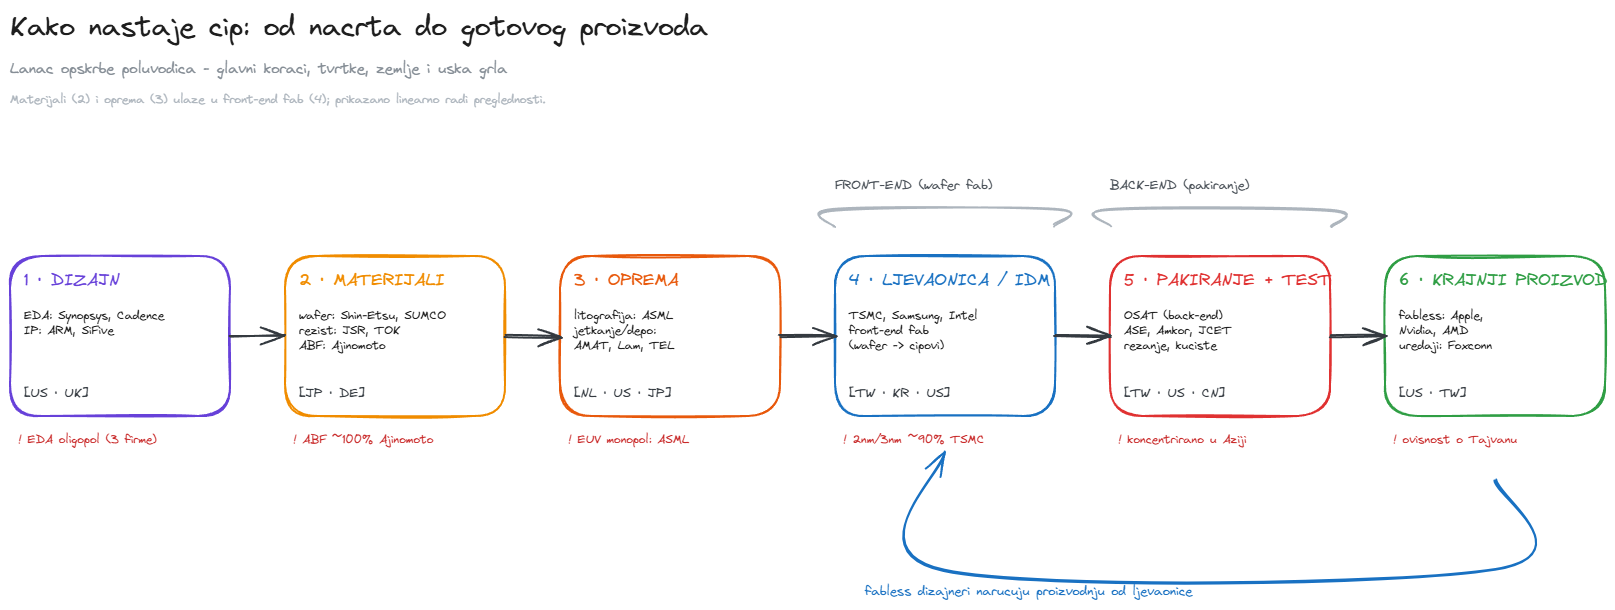

In [1]:
# Dijagram toka proizvodnje cipa (izvezeno iz Excalidrawa).
# Izvor/uredjivanje: reports/diagrams/chip_supply_chain.excalidraw (excalidraw.com)
from pathlib import Path
from IPython.display import Image, display

_p = Path.cwd()
while not (_p / "reports" / "diagrams").exists() and _p != _p.parent:
    _p = _p.parent
display(Image(filename=str(_p / "reports" / "diagrams" / "diagram_png.excalidraw.png"),
              width=1100))

### Sažeta tablica vrijednosnog lanca

| Korak | Što se događa | Ključne tvrtke | Zemlje | Materijali / alati |
|---|---|---|---|---|
| **Dizajn** | logika čipa se projektira | Synopsys, Cadence, ARM, Nvidia, Apple | 🇺🇸 🇬🇧 | EDA softver, IP jezgre |
| **Materijali** | sirovine za proizvodnju | Shin-Etsu, SUMCO, JSR, Ajinomoto | 🇯🇵 🇩🇪 | silicijski wafer, fotorezist, ABF, plinovi |
| **Oprema** | strojevi za front-end | ASML, Applied Materials, Lam, Tokyo Electron, KLA | 🇳🇱 🇺🇸 🇯🇵 | EUV/DUV litografija, jetkanje, depozicija |
| **Ljevaonica/IDM** | wafer → čipovi (front-end) | TSMC, Samsung, Intel, GlobalFoundries | 🇹🇼 🇰🇷 🇺🇸 | čista soba, stotine procesnih koraka |
| **Pakiranje+test** | rezanje, test, kućište (back-end) | ASE, Amkor, JCET, Powertech | 🇹🇼 🇺🇸 🇨🇳 | bonderi, podloge, kalupi |
| **Krajnji proizvod** | čip u uređaju | Apple, Nvidia, AMD, Foxconn | 🇺🇸 🇹🇼 | gotovi čipovi |

Upravo **ove tvrtke, veze i ovisnosti** su ono što ćemo sada formalno modelirati
kao graf i analizirati.

## 1. Postavljanje i učitavanje grafa

Sve analize čitaju **NetworkX zrcalo** grafa iz `data/processed/graph.pkl`.
To je „zamrznuta“ kopija grafa koji živi u Neo4j bazi — tok podataka je:

```
CSV (data/raw)  →  Neo4j (graf-baza)  →  graph.pkl (NetworkX, za brzu analizu)
   IZVOR ISTINE      UPITI/VIZUALIZACIJA     OVO UČITAVAMO U PYTHONU
```

Pomoćne funkcije u `scripts/analysis.py` daju nam dosljedne *projekcije* grafa
da svi notebookovi gledaju isto.

In [2]:
import sys, warnings
from pathlib import Path
from collections import Counter
warnings.filterwarnings('ignore')

# pronađi korijen projekta (gdje je scripts/analysis.py) i dodaj na put
ROOT = Path.cwd()
while not (ROOT / 'scripts' / 'analysis.py').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'scripts'))

import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import analysis

g = analysis.full_graph()          # cijeli graf (svi tipovi čvorova i veza)
print(f'Učitan graf: {g.number_of_nodes()} čvorova, {g.number_of_edges()} veza')
print(f'Tip objekta: {type(g).__name__} (usmjeren multigraf)')

Učitan graf: 207 čvorova, 1643 veza
Tip objekta: MultiDiGraph (usmjeren multigraf)


## 2. Što je u grafu? (struktura i shema)

Graf ima **4 tipa čvorova** i **6 tipova veza**. Ovo je „rječnik“ modela:

| Čvor | Značenje |
|---|---|
| `Company` | tvrtka (oprema, materijali, ljevaonica, fabless, IDM, EMS…) |
| `Country` | zemlja (s BDP-om i indeksom političke stabilnosti) |
| `Product` | proizvod/tehnologija (logički wafer, memorija, oprema, materijal…) |
| `Facility` | tvornica/pogon (fab, montaža, R&D) |

| Veza | Od → Do | Značenje |
|---|---|---|
| `SUPPLIES` | Company → Company | tko koga opskrbljuje |
| `MANUFACTURES` | Company → Product | tko što proizvodi (+ udio kapaciteta) |
| `LOCATED_IN` | Company → Country | gdje je tvrtka |
| `OPERATES` | Company → Facility | tko upravlja tvornicom |
| `COMPETES_WITH` | Company → Company | konkurencija |
| `DEPENDS_ON` | Product → Product | tehnološka ovisnost proizvoda |

**Pravilo projekta:** svaka `SUPPLIES` i `MANUFACTURES` veza ima zabilježen
izvor (URL + datum). Nema podatka bez izvora.

In [3]:
labels = Counter(d['label'] for _, d in g.nodes(data=True))
rels = Counter(d['rel_type'] for *_, d in g.edges(data=True))
print('Čvorovi po tipu:')
for k, v in labels.most_common():
    print(f'  {k:10s} {v}')
print('\nVeze po tipu:')
for k, v in rels.most_common():
    print(f'  {k:14s} {v}')

Čvorovi po tipu:
  Company    108
  Product    68
  Facility   18
  Country    13

Veze po tipu:
  SUPPLIES       1256
  MANUFACTURES   171
  LOCATED_IN     108
  COMPETES_WITH  45
  DEPENDS_ON     45
  OPERATES       18


## 3. Projekcija SUPPLIES — objekt analize

Hipoteza govori o tome **„tko koga opskrbljuje“**, pa glavninu analize radimo na
**projekciji SUPPLIES**: zadržimo samo `Company` čvorove i `SUPPLIES` veze.

Jedna tehnička napomena: između istog para tvrtki može postojati više
`SUPPLIES` veza (različite kategorije proizvoda). U projekciji ih **sažimamo u
jedan usmjereni brid** čiji atribut `weight` broji koliko ih je bilo. Zato je
broj bridova u projekciji manji od ukupnog broja `SUPPLIES` redaka.

In [4]:
D = analysis.company_supply_digraph(g)      # usmjerena Company→Company (SUPPLIES)
U = D.to_undirected(as_view=False)          # neusmjerena inačica (za neke mjere)
print(f'Projekcija SUPPLIES: {D.number_of_nodes()} tvrtki, '
      f'{D.number_of_edges()} usmjerenih veza')

Projekcija SUPPLIES: 108 tvrtki, 1256 usmjerenih veza


## 4. (L2) Osnovna svojstva grafa

Prije „pametnih“ mjera, pogledajmo osnovne brojke:
- **Gustoća** — koliki udio svih mogućih veza zapravo postoji (0 = prazno, 1 = svi povezani sa svima).
- **Prosječan / maksimalan stupanj** — koliko veza tipično/najviše ima jedan čvor.
- Mreža je rijetka (malen udio mogućih veza), ali s nekoliko vrlo povezanih čvorišta — prvi nagovještaj „hub“ strukture.

In [5]:
deg = dict(U.degree())
print(f'Gustoća (usmjerena): {nx.density(D):.4f}')
print(f'Prosječan stupanj  : {np.mean(list(deg.values())):.1f}')
print(f'Maksimalan stupanj : {max(deg.values())}  '
      f'({max(deg, key=deg.get)})')
print(f'Minimalan stupanj  : {min(deg.values())}')

Gustoća (usmjerena): 0.1087
Prosječan stupanj  : 23.3
Maksimalan stupanj : 61  (TSMC)
Minimalan stupanj  : 1


## 5. (L3) Centralnost — tko su uska grla?

„Centralnost“ mjeri **koliko je čvor važan**, ali važnost ima više značenja, pa
računamo nekoliko mjera koje se namjerno **ne slažu** — i baš to neslaganje je
nalaz:

| Mjera | Čita se kao |
|---|---|
| **stupanj (in/out)** | izravan doseg — mnogo dobavljača/kupaca |
| **betweenness** | posredništvo — udio opskrbnih putova koji prolaze kroz tvrtku |
| **closeness** | koliko brzo tvrtka dosegne ostatak lanca |
| **eigenvector / pagerank** | utjecaj — povezanost s *važnim* tvrtkama |

Betweenness je ovdje ključan: tvrtka s **visokim betweennessom** je strukturno
**usko grlo** — kroz nju prolaze putovi koje ne dominira pukim brojem veza.

In [6]:
betw = nx.betweenness_centrality(D, normalized=True)
clos = nx.closeness_centrality(D)
eig = nx.eigenvector_centrality(U, max_iter=1000)
pr = nx.pagerank(D)

cent = pd.DataFrame({
    'tip': dict(D.nodes(data='type')),
    'in_deg': dict(D.in_degree()),
    'out_deg': dict(D.out_degree()),
    'betweenness': betw,
    'closeness': clos,
    'eigenvector': eig,
    'pagerank': pr,
}).round(4).sort_values('betweenness', ascending=False)
cent.head(12)

,tip,in_deg,out_deg,betweenness,closeness,eigenvector,pagerank
TSMC,fab,44,17,0.0289,0.4212,0.1594,0.0128
ASML,equipment,3,27,0.0056,0.0280,0.1200,0.0090
Samsung Foundry,fab,39,5,0.0054,0.3677,0.1401,0.0110
Apple,fabless,28,1,0.0041,0.4308,0.0902,0.0708
SK Hynix,IDM,33,5,0.0038,0.3121,0.1308,0.0086
UMC,fab,32,5,0.0035,0.3067,0.1295,0.0088
Samsung Memory,IDM,33,5,0.0031,0.3121,0.1325,0.0086
Tokyo Electron,equipment,3,27,0.0030,0.0280,0.1202,0.0067
Applied Materials,equipment,3,27,0.0030,0.0280,0.1202,0.0067
Lam Research,equipment,3,27,0.0030,0.0280,0.1202,0.0067


Pogledajmo gdje se nalaze **imenovani čvorišni kandidati iz hipoteze**
(TSMC, ASML, Shin-Etsu, Air Products, ARM) po raznim mjerama — rang 1 = najviši
od svih 108 tvrtki.

In [7]:
named = ['TSMC', 'ASML', 'Shin-Etsu Chemical', 'Air Products', 'ARM']
ranks = {}
for m in ['betweenness', 'out_deg', 'closeness', 'pagerank']:
    order = cent[m].sort_values(ascending=False)
    ranks[m] = {c: int(order.index.get_loc(c)) + 1 for c in named}
pd.DataFrame(ranks)

,betweenness,out_deg,closeness,pagerank
TSMC,1,39,3,15
ASML,2,4,53,33
Shin-Etsu Chemical,52,9,76,76
Air Products,100,21,101,101
ARM,68,38,84,84


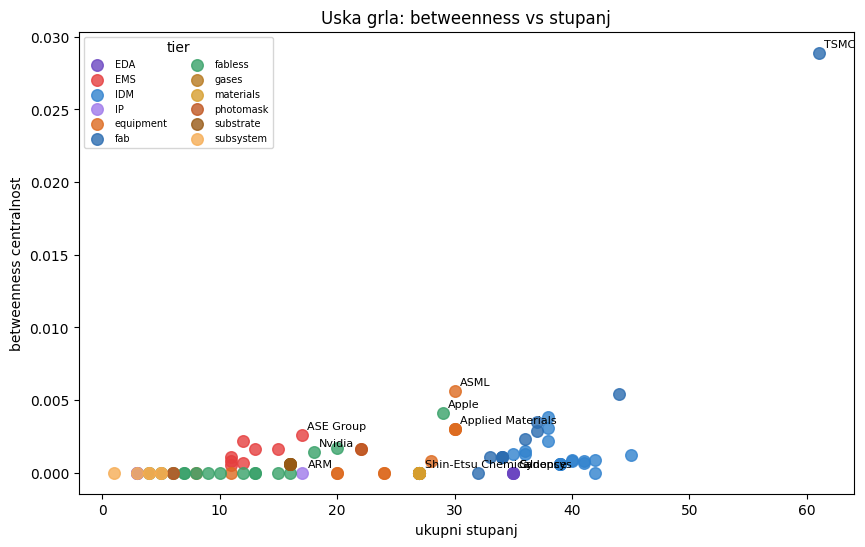

In [8]:
# Vizualizacija: betweenness vs stupanj — tko broka više nego što "drži"
fig, ax = plt.subplots(figsize=(10, 6))
for t, sub in cent.groupby('tip'):
    ax.scatter(sub['in_deg'] + sub['out_deg'], sub['betweenness'],
               s=70, alpha=0.8, label=t, color=analysis.tier_color(t))
for name in ['TSMC', 'ASML', 'Shin-Etsu Chemical', 'Applied Materials',
             'Synopsys', 'Cadence', 'ARM', 'ASE Group', 'Nvidia', 'Apple']:
    if name in cent.index:
        r = cent.loc[name]
        ax.annotate(name, (r['in_deg'] + r['out_deg'], r['betweenness']),
                    fontsize=8, xytext=(4, 4), textcoords='offset points')
ax.set(xlabel='ukupni stupanj', ylabel='betweenness centralnost',
       title='Uska grla: betweenness vs stupanj')
ax.legend(title='tier', fontsize=7, ncol=2); plt.show()

**Tumačenje.** Na vrhu betweennessa i out-stupnja su **uzvodni omogućivači**
koji prodaju cijeloj industriji: oprema (ASML, Applied Materials, Lam, Tokyo
Electron), EDA (Synopsys, Cadence) i materijali. **TSMC** je poseban — visok i po
*ulaznom* stupnju i po posredništvu: upija cijeli uzvodni lanac i hrani gotovo
sve fabless dizajnere. To su klasična uska grla.

## 6. (L4) Povezanost — artikulacijske točke i mostovi

Sada tražimo **strukturno nezamjenjive** čvorove:
- **Komponente** — je li graf u jednom komadu?
- **Acikličnost (DAG)** — teče li opskrba samo „naprijed“ (uzvodno → nizvodno)?
- **Artikulacijska točka** — čvor čije uklanjanje **rascijepi** graf na više dijelova (jedna točka otkaza za *povezanost*).
- **Most** — veza čije uklanjanje rascijepi graf.
- **Globalna povezanost čvorova (κ)** — koliko najmanje čvorova treba maknuti da graf raspadne.

In [9]:
print('Slabo povezanih komponenti :', nx.number_weakly_connected_components(D))
print('Neusmjereno povezan?        :', nx.is_connected(U))
print('Acikličan (DAG)?            :', nx.is_directed_acyclic_graph(D))

ap = sorted(nx.articulation_points(U))
bridges = sorted(nx.bridges(U))
print('Artikulacijske točke        :', ap)
print('Mostovi                     :', bridges)
print('Globalna povezanost κ       :', nx.node_connectivity(U))

pendants = sorted(n for n, d in U.degree() if d == 1)
print(f'\nViseći (pendant) čvorovi ({len(pendants)}):')
for p in pendants:
    print(f'  {p:26s} -> spojen jedino preko {next(iter(U.neighbors(p)))}')

Slabo povezanih komponenti : 1
Neusmjereno povezan?        : True
Acikličan (DAG)?            : True
Artikulacijske točke        : ['ASML']
Mostovi                     : [('Carl Zeiss SMT', 'ASML')]
Globalna povezanost κ       : 1

Viseći (pendant) čvorovi (1):
  Carl Zeiss SMT             -> spojen jedino preko ASML


**Tumačenje.** Mreža je **jedna povezana, aciklična** cjelina (oblik pravog
lanca opskrbe). Postoji **točno jedna artikulacijska točka — ASML** — spojena
jednim **mostom** na svog jedinog dobavljača EUV-optike (Carl Zeiss SMT, viseći
čvor). Dakle κ = 1: jedno dobro odabrano uklanjanje *može* rascijepiti graf.
Inače je mreža **redundantna** — svaki drugi sloj ima više zamjenjivih
dobavljača. Tvrdnja hipoteze o „nezamjenjivim tvrtkama“ vrijedi **usko** (ASML),
ne široko.

## 7. (L5) Zajednice — klasteri po ulozi ili po geografiji?

**Louvain** algoritam traži „zajednice“ — skupine čvorova gušće povezane unutar
sebe nego prema van. Pitanje: grupira li se lanac po **tieru** (što tvrtka radi)
ili po **geografiji** (gdje je)?

Mjerimo **modularnost Q** (koliko je dobra podjela): pozitivno = klasteri,
**negativno = „anti-zajednica“** (članovi su *manje* povezani međusobno nego
slučajno).

In [10]:
comms = sorted(nx.community.louvain_communities(U, weight='weight', seed=42),
               key=len, reverse=True)
part = {n: i for i, c in enumerate(comms) for n in c}
Q = nx.community.modularity(U, comms, weight='weight')

def part_by(attr):
    grp = {}
    for n, v in U.nodes(data=attr):
        grp.setdefault(v, set()).add(n)
    return list(grp.values())

Q_tier = nx.community.modularity(U, part_by('type'), weight='weight')
Q_region = nx.community.modularity(U, part_by('region'), weight='weight')
print(f'Louvain: {len(comms)} zajednice, modularnost Q = {Q:.3f}')
print(f'Modularnost po TIERU     : {Q_tier:.3f}')
print(f'Modularnost po REGIJI    : {Q_region:.3f}')

Louvain: 3 zajednice, modularnost Q = 0.220
Modularnost po TIERU     : -0.151
Modularnost po REGIJI    : 0.030


**Tumačenje.** Modularnost po **tieru je negativna** → tvrtke istog tipa
se međusobno gotovo **ne** opskrbljuju: to je potpis **višedijelne (multipartite)**
mreže (oprema → ljevaonica → fabless). Geografija je tek **slabo** pozitivna —
opskrba je globalna (japanski materijali → tajvanske ljevaonice → američki
fabless). Zaključak: mrežu organizira **uloga u lancu**, ne država.

## 8. (L6/L7) Slučajni model (ER) i small-world

Da bismo znali je li struktura mreže „posebna“, uspoređujemo je sa **slučajnim
Erdős–Rényi (ER)** grafom istog broja čvorova i veza. Mjerimo:
- **C** = koeficijent grupiranja (koliko su susjedi nekog čvora i međusobno susjedi).
- **L** = prosječna duljina najkraćeg puta.

**Small-world** mreža ima **kratke putove** *i* **visoko grupiranje**
(σ = (C/C_ER)/(L/L_ER) > 1).

In [11]:
G = analysis.giant_component(U)
n, m = G.number_of_nodes(), G.number_of_edges()
C_real = nx.average_clustering(G)
L_real = nx.average_shortest_path_length(G)

rng = np.random.default_rng(42)
Cs, Ls = [], []
for _ in range(50):
    R = nx.gnm_random_graph(n, m, seed=int(rng.integers(1e9)))
    if not nx.is_connected(R):
        R = R.subgraph(max(nx.connected_components(R), key=len)).copy()
    Cs.append(nx.average_clustering(R)); Ls.append(nx.average_shortest_path_length(R))
C_er, L_er = np.mean(Cs), np.mean(Ls)
sigma = (C_real / C_er) / (L_real / L_er)
print(f'STVARNO : C = {C_real:.3f}   L = {L_real:.3f}')
print(f'ER       : C = {C_er:.3f}   L = {L_er:.3f}')
print(f'small-world σ = {sigma:.2f}')

STVARNO : C = 0.086   L = 1.991
ER       : C = 0.217   L = 1.787
small-world σ = 0.36


**Tumačenje.** Putovi su **kratki** (L ≈ 2 — svaka tvrtka do svake u ~2
koraka), ali **grupiranje je *niže* od slučajnog** (σ ≈ 0.4 < 1). Dakle mreža
**nije** klasičan small-world: zbog višedijelne strukture dobavljači nekog čvora
rijetko opskrbljuju jedni druge, pa nema „trokuta“. Kratke putove stvara
nekoliko hubova koji premošćuju slojeve, ne gusta lokalna susjedstva.

## 9. (L8) Distribucija stupnjeva — je li mreža scale-free?

„Scale-free“ znači da distribucija stupnjeva slijedi **zakon potencije**
(power-law) — malo super-povezanih hubova, mnogo slabo povezanih. Testiramo to
**pošteno** paketom `powerlaw`: uspoređujemo power-law s **lognormalnom**
alternativom (R > 0 i mali p ⇒ power-law bolji).

In [12]:
import powerlaw
degree = np.array([d for _, d in U.degree()])
fit = powerlaw.Fit(degree, discrete=True, verbose=False)
print(f'Procijenjeni α = {fit.power_law.alpha:.2f}, xmin = {fit.power_law.xmin:.0f}')
R, p = fit.distribution_compare('power_law', 'lognormal', normalized_ratio=True)
print(f'power-law vs lognormal: R = {R:+.2f}, p = {p:.3f}')
print('→ ' + ('power-law bolji' if R > 0 and p < 0.05 else
       'NEMA jasne prednosti power-lawa (mreža nije čisto scale-free)'))

Procijenjeni α = 8.77, xmin = 35


power-law vs lognormal: R = -0.30, p = 0.767
→ NEMA jasne prednosti power-lawa (mreža nije čisto scale-free)


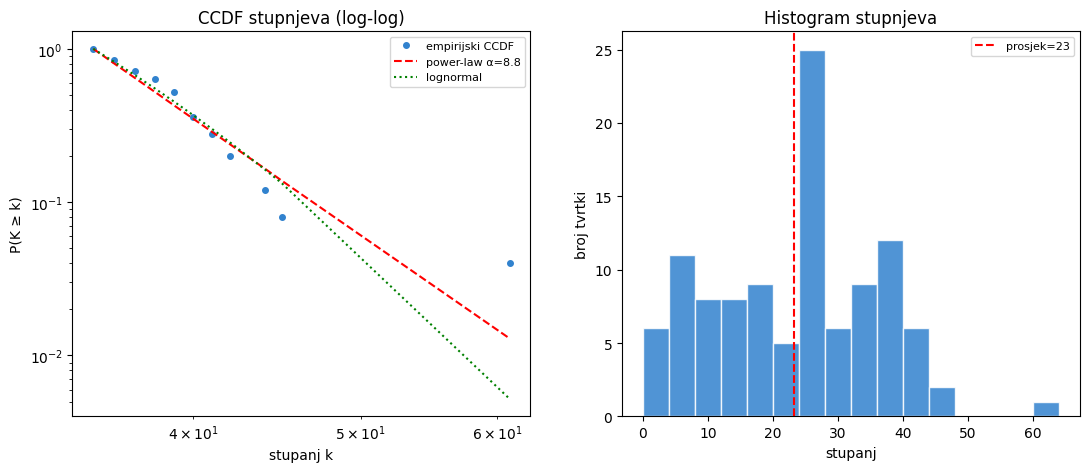

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
fit.plot_ccdf(ax=ax[0], color='#3182ce', marker='o', ms=4, lw=0, label='empirijski CCDF')
fit.power_law.plot_ccdf(ax=ax[0], color='red', ls='--', label=f'power-law α={fit.power_law.alpha:.1f}')
fit.lognormal.plot_ccdf(ax=ax[0], color='green', ls=':', label='lognormal')
ax[0].set(xlabel='stupanj k', ylabel='P(K ≥ k)', title='CCDF stupnjeva (log-log)'); ax[0].legend(fontsize=8)
ax[1].hist(degree, bins=range(0, degree.max() + 4, 4), color='#3182ce', alpha=0.85, edgecolor='white')
ax[1].axvline(degree.mean(), color='red', ls='--', label=f'prosjek={degree.mean():.0f}')
ax[1].set(xlabel='stupanj', ylabel='broj tvrtki', title='Histogram stupnjeva'); ax[1].legend(fontsize=8)
plt.show()

**Tumačenje.** Distribucija **jest** desno-zakrivljena s jasnim hubovima,
ali **čisti power-law nije statistički bolji** od lognormalne (p ≫ 0.05). Na
ovako maloj i gustoj mreži ne možemo tvrditi „scale-free“ — pošten opis je
„dominirana hubovima i teško-repna“. Formalni dio hipoteze ovdje **ne prolazi**.

## 10. (L9) Otpornost — ciljani vs slučajni napad

Ovo je odlučujući test: uklanjamo čvorove i gledamo kako se topi **velika
povezana komponenta (GCC)**. Tri redoslijeda:
- **ciljano po stupnju** i **ciljano po betweennessu** (napad na hubove),
- **slučajno** (prosjek 30 pokušaja).

Ako je hipoteza točna, ciljani napad bi trebao biti **puno** razorniji, a 3–5
hubova bi trebalo izazvati **katastrofalnu** fragmentaciju.

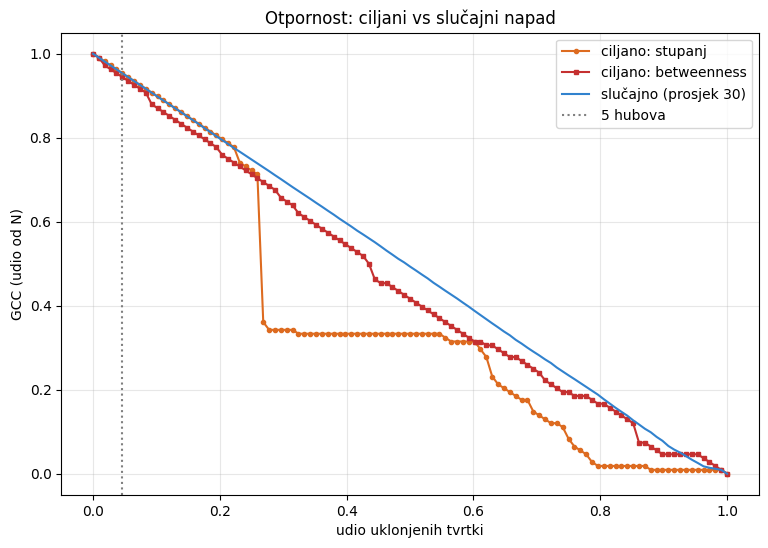

In [14]:
N = U.number_of_nodes()
def attack(order):
    H = U.copy(); xs=[0.0]; ys=[1.0]
    for i, node in enumerate(order):
        if node in H: H.remove_node(node)
        xs.append((i+1)/N)
        ys.append((max((len(c) for c in nx.connected_components(H)), default=0))/N)
    return np.array(xs), np.array(ys)

deg_order = [x for x, _ in sorted(U.degree(), key=lambda t: t[1], reverse=True)]
bet_order = sorted(betw, key=betw.get, reverse=True)
x, y_deg = attack(deg_order); _, y_bet = attack(bet_order)
nodes = list(U.nodes()); runs = []
for _ in range(30):
    rng.shuffle(nodes); _, yr = attack(list(nodes)); runs.append(yr)
y_rand = np.mean(runs, axis=0)

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(x, y_deg, '-o', ms=3, color='#dd6b20', label='ciljano: stupanj')
ax.plot(x, y_bet, '-s', ms=3, color='#c53030', label='ciljano: betweenness')
ax.plot(x, y_rand, '-', color='#3182ce', label='slučajno (prosjek 30)')
ax.axvline(5/N, color='gray', ls=':', label='5 hubova')
ax.set(xlabel='udio uklonjenih tvrtki', ylabel='GCC (udio od N)',
       title='Otpornost: ciljani vs slučajni napad'); ax.legend(); ax.grid(alpha=0.3)
plt.show()

In [15]:
hubs = ['TSMC', 'ASML', 'Shin-Etsu Chemical', 'Air Products', 'ARM']
H = U.copy(); H.remove_nodes_from(hubs)
gcc = max(len(c) for c in nx.connected_components(H))
print(f'Uklanjanje 5 imenovanih hubova → GCC = {gcc}/{N} ({gcc/N:.0%}); '
      f'komponenti: {nx.number_connected_components(H)}')

Uklanjanje 5 imenovanih hubova → GCC = 102/108 (94%); komponenti: 2


**Tumačenje.** Ciljani napad **jest** razorniji od slučajnog (potpis
hub-ovisne mreže) — *smjer* hipoteze je točan. Ali uklanjanje 5 imenovanih
hubova ostavlja **~94%** tvrtki povezano: **nema** katastrofalne fragmentacije.
Na razini *tvrtki* mreža je robusna zbog redundancije. **No** — ovaj test broji
samo čvorove, ne i *koliko* svaki proizvodi. Taj nedostatak ispravljamo dalje.

## 11. Proširenje: koncentracija i težinska otpornost

Topološka analiza tretira sve veze jednako. Ali čvor kroz koji ide **80%**
proizvodnje i onaj s **5%** izgledaju jednako — pa graf može izgledati „robusno“
dok bi gubitak ključnog čvora bio katastrofalan.

Zato dodajemo dimenziju **„koliko“** koristeći `capacity_share_pct` (udio
proizvodnog kapaciteta, osvježen tržišnim podacima 2024.). Računamo:
1. **single-source** proizvode (samo jedan proizvođač — nezamjenjivo),
2. **production-at-risk** rang po tvrtki,
3. **kapacitetom-ponderiranu otpornost**.

In [16]:
conc = analysis.product_concentration(g)
single = sorted(p for p, c in conc.items() if c['single_source'])
print(f'Proizvodi s jednim jedinim proizvođačem ({len(single)}):')
for p in single:
    print(f'  {p:30s} -> {conc[p]["makers"][0]}')

Proizvodi s jednim jedinim proizvođačem (15):
  2nm logic wafer                -> TSMC
  ABF build-up film              -> Ajinomoto
  CMOS image sensor              -> onsemi
  CMP system                     -> Applied Materials
  Dicing saw                     -> Disco Corporation
  EUV lithography system         -> ASML
  EUV mask blank                 -> Hoya
  EUV mask inspection system     -> Lasertec
  EUV optics module              -> Carl Zeiss SMT
  Ion implanter                  -> Applied Materials
  Nanoimprint lithography system -> Canon
  PVD deposition system          -> Applied Materials
  RISC-V IP core                 -> SiFive
  SOI wafer                      -> Soitec
  Wire bonder                    -> Kulicke & Soffa


Ovih ~15 proizvoda su **prave** jedinstvene točke otkaza (EUV litografija →
ASML, EUV optika → Zeiss, EUV mask blank → Hoya, mask inspekcija → Lasertec,
ABF film → Ajinomoto, 2nm → TSMC…). To su uska grla iza krize 2020.–2022.

In [17]:
risk = analysis.production_at_risk(g)
Wt = sum(r['controlled'] for r in risk.values())
df_risk = (pd.DataFrame([
    {'tvrtka': c, 'kontrola': r['controlled'], 'single_source': r['single_source'],
     'broj_SS': r['n_single_source'], '%_ukupno': round(100*r['controlled']/Wt, 1)}
    for c, r in risk.items()])
    .sort_values(['single_source', 'kontrola'], ascending=False).reset_index(drop=True))
df_risk.head(12)

,tvrtka,kontrola,single_source,broj_SS,%_ukupno
0,ASML,180.0,100.0,1,5.3
1,Lasertec,100.0,100.0,1,3.0
2,Carl Zeiss SMT,100.0,100.0,1,3.0
3,Ajinomoto,100.0,100.0,1,3.0
4,TSMC,465.0,90.0,1,13.7
5,Hoya,140.0,70.0,1,4.1
6,Disco Corporation,70.0,70.0,1,2.1
7,Soitec,70.0,70.0,1,2.1
8,Kulicke & Soffa,60.0,60.0,1,1.8
9,Canon,16.0,8.0,1,0.5


**Production-at-risk:** `kontrola` = ukupni kapacitet koji tvrtka drži;
`single_source` = onaj dio na proizvodima gdje je **jedini** proizvođač
(nezamjenjivo). ASML, Lasertec, Zeiss i Ajinomoto su 100% nezamjenjivi; TSMC
drži najviše ukupno.

Uklanjanje 5 hubova → čvorova u GCC: 94%, proizvodnog kapaciteta: 74%


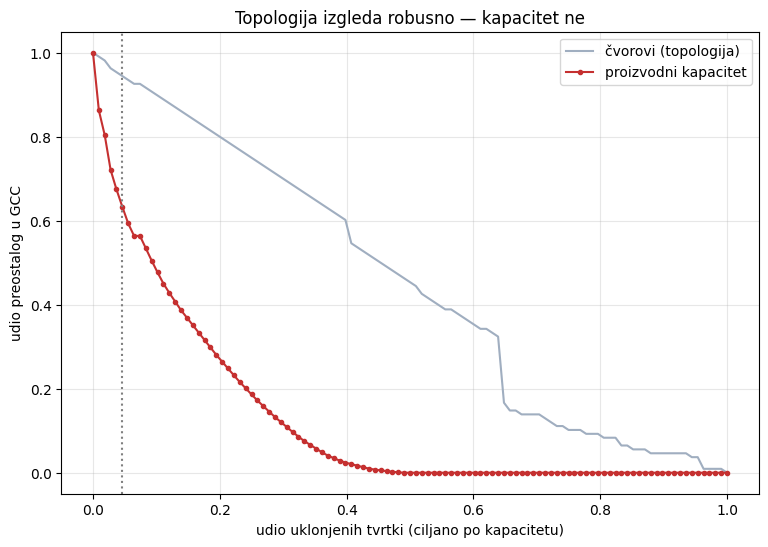

In [18]:
# Kapacitetom-ponderirana otpornost: pratimo udio PROIZVODNJE u GCC-u
w = analysis.production_weight(g); W = sum(w.values())
def attack_w(order):
    H = U.copy(); xs=[0.0]; nod=[1.0]; cap=[1.0]
    for i, node in enumerate(order):
        if node in H: H.remove_node(node)
        xs.append((i+1)/N)
        if H.number_of_nodes():
            gcc = max(nx.connected_components(H), key=len)
            nod.append(len(gcc)/N); cap.append(sum(w.get(x, 0) for x in gcc)/W)
        else:
            nod.append(0); cap.append(0)
    return np.array(xs), np.array(nod), np.array(cap)

order_w = sorted(U.nodes(), key=lambda n: w.get(n, 0), reverse=True)
xw, n_topo, n_cap = attack_w(order_w)
H = U.copy(); H.remove_nodes_from(hubs); gcc = max(nx.connected_components(H), key=len)
print(f'Uklanjanje 5 hubova → čvorova u GCC: {len(gcc)/N:.0%}, '
      f'proizvodnog kapaciteta: {sum(w.get(x,0) for x in gcc)/W:.0%}')

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(xw, n_topo, color='#a0aec0', label='čvorovi (topologija)')
ax.plot(xw, n_cap, '-o', ms=3, color='#c53030', label='proizvodni kapacitet')
ax.axvline(5/N, color='gray', ls=':')
ax.set(xlabel='udio uklonjenih tvrtki (ciljano po kapacitetu)',
       ylabel='udio preostalog u GCC', title='Topologija izgleda robusno — kapacitet ne')
ax.legend(); ax.grid(alpha=0.3); plt.show()

**Tumačenje (ključno!).** Uklanjanje 5 hubova ostavlja ~94% *tvrtki*, ali
samo **~74% proizvodnog kapaciteta**. Topološka „robusnost“ je bila **artefakt**
zanemarivanja količine. Prave točke loma su **proizvodi/tehnologije** s jednim
proizvođačem, ne cijele tvrtke.

## 12. Null-model testiranje — jesu li nalazi statistički značajni?

Dosadašnje mjere (grupiranje, modularnost, artikulacijske točke, otpornost) su
**deskriptivne** — opisuju graf, ali ne kažu je li ono što vidimo *više nego što
bi se očekivalo slučajno*. Da bismo to znali, trebamo **null model**.

Koristimo **konfiguracijski null model uz očuvanje stupnjeva**
(*degree-preserving randomization*): uzmemo stvarni graf i nasumično
ispremiješamo bridove (`nx.double_edge_swap`) tako da **svaki čvor zadrži točno
isti stupanj**, ali se *tko-je-s-kim* slučajno presloži. Time kontroliramo
distribuciju stupnjeva — pa svako odstupanje opaženog od null-a znači **prava
struktura iznad same distribucije stupnjeva**, a ne artefakt toga što neki čvorovi
imaju puno veza.

Za svaku mjeru generiramo ansambl od 100 takvih slučajnih grafova, izračunamo
**z-score** = (opaženo − prosjek_null) / sd_null i **empirijsku p-vrijednost**.
Pravilo: |z| > 2 (p < 0.05) ⇒ statistički značajno različito od slučajnog.

In [19]:
def _robustness(G):
    # AUC krivulje velike komponente pod ciljanim (degree) napadom; nize = krhkije
    H = G.copy(); N = H.number_of_nodes(); ys = [1.0]
    for n in [x for x, _ in sorted(H.degree(), key=lambda t: t[1], reverse=True)]:
        if n in H:
            H.remove_node(n)
        ys.append(max((len(c) for c in nx.connected_components(H)), default=0) / N)
    return float(np.mean(ys))

def _metrics(G):
    gc = G if nx.is_connected(G) else G.subgraph(max(nx.connected_components(G), key=len)).copy()
    cm = nx.community.louvain_communities(G, seed=1, weight=None)
    return dict(C=nx.average_clustering(G),
                L=nx.average_shortest_path_length(gc),
                Q=nx.community.modularity(G, cm, weight=None),
                AP=len(list(nx.articulation_points(G))),
                ROB=_robustness(G))

obs = _metrics(U)
m = U.number_of_edges()
rng = np.random.default_rng(7)
NULLS = 100
acc = {k: [] for k in obs}
for _ in range(NULLS):
    R = U.copy()
    try:
        nx.double_edge_swap(R, nswap=10 * m, max_tries=200 * m, seed=int(rng.integers(1e9)))
    except nx.NetworkXAlgorithmError:
        pass
    mm = _metrics(R)
    for k in obs:
        acc[k].append(mm[k])

labels = {'C': 'grupiranje C', 'L': 'prosj. put L', 'Q': 'modularnost Q',
          'AP': '# artikulacijskih tocaka', 'ROB': 'otpornost (AUC, degree napad)'}
rows = []
for k in ['C', 'L', 'Q', 'AP', 'ROB']:
    a = np.array(acc[k]); mu = a.mean(); sd = a.std() or 1e-9
    z = (obs[k] - mu) / sd
    p = min(1.0, 2 * min(np.mean(a >= obs[k]), np.mean(a <= obs[k])))
    rows.append([labels[k], round(obs[k], 3), f'{mu:.3f} ± {sd:.3f}',
                 round(z, 1), round(p, 3), 'da' if abs(z) > 2 else 'NE'])
pd.DataFrame(rows, columns=['mjera', 'opazeno', 'null (prosjek ± sd)',
                            'z', 'p (dvostrano)', 'znacajno?'])

,mjera,opazeno,null (prosjek ± sd),z,p (dvostrano),znacajno?
0,grupiranje C,0.086,0.355 ± 0.009,-29.4,0.0,da
1,prosj. put L,1.991,1.868 ± 0.005,23.7,0.0,da
2,modularnost Q,0.219,0.128 ± 0.005,18.2,0.0,da
3,# artikulacijskih tocaka,1.000,1.000 ± 0.000,0.0,1.0,NE
4,"otpornost (AUC, degree napad)",0.374,0.416 ± 0.007,-5.9,0.0,da


**Tumačenje (ovo je ono što projektu daje statističku težinu):**

- **Grupiranje C** je *dramatično ispod* slučajnog (z ≈ −30, p < 0.001). Niska
  grupiranost iz L7 **nije** artefakt stupnjeva — višedijelna (tier→tier)
  struktura stvarno potiskuje trokute. Nalaz **opstaje** strogom testu.
- **Modularnost Q** je *iznad* slučajnog (z ≈ +19, p < 0.001) → zajednice su
  **stvarne**, a ne posljedica toga što par čvorova ima velik stupanj. Nalaz iz
  L5 **opstaje**.
- **Prosječni put L** je statistički *malo iznad* null-a (z ≈ +30, ali apsolutno
  +0.12) — značajno, no praktički sitno.
- **Otpornost** (degree napad) je *ispod* null-a (z ≈ −6, p < 0.001): mreža je
  **krhkija na ciljani napad nego što sama distribucija stupnjeva nalaže** →
  strukturna potpora tvrdnji o krhkosti (L9).
- **Artikulacijske točke**: opaženo = null = **točno 1** (z = 0, p = 1.0).
  Ovdje smo **pošteni**: jedina artikulacijska točka je *trivijalna* posljedica
  jednog visećeg čvora (Carl Zeiss SMT, stupanj 1) — svaki degree-preserving graf
  također ima točno jednu. **To NIJE duboko strukturno svojstvo.**

> Upravo to je svrha null modela: razdvojiti **pravu strukturu** (C, Q, otpornost
> — značajni) od **artefakta stupnjeva** (broj artikulacijskih točaka — nije).
> Četiri od pet ključnih nalaza prolaze strogi test, što ih čini statistički
> obranjivima, a ne tek deskriptivnim opažanjima.

## 13. Sinteza i konačni zaključak

Sažmimo svaki dio hipoteze i presudimo na temelju podataka.

In [20]:
verdict = pd.DataFrame([
    ['Scale-free (L8)', 'power-law dominira', 'NE — lognormal jednako dobar', '✗'],
    ['Small-world (L7)', 'kratki putovi + visoko grupiranje', 'DJELOMIČNO — kratki putovi, nisko grupiranje', '~'],
    ['Nezamjenjivi hubovi (L4)', 'više kritičnih tvrtki', 'USKO — samo ASML je artikulacijska točka', '~'],
    ['Hub-ovisnost (L9)', 'ciljani napad razorniji', 'DA', '✓'],
    ['Katastrofa od 5 hubova (L9)', 'raspad GCC-a', 'NE topološki (94%); ALI 26% kapaciteta nestane', '~'],
    ['Prava krhkost', 'na razini tvrtki', 'NE — na razini monopolskih inputa (EUV, ABF)', '✗→✓'],
], columns=['Tvrdnja', 'Hipoteza kaže', 'Podaci pokazuju', 'Ocjena'])
verdict

,Tvrdnja,Hipoteza kaže,Podaci pokazuju,Ocjena
0,Scale-free (L8),power-law dominira,NE — lognormal jednako dobar,✗
1,Small-world (L7),kratki putovi + visoko grupiranje,"DJELOMIČNO — kratki putovi, nisko grupiranje",~
2,Nezamjenjivi hubovi (L4),više kritičnih tvrtki,USKO — samo ASML je artikulacijska točka,~
3,Hub-ovisnost (L9),ciljani napad razorniji,DA,✓
4,Katastrofa od 5 hubova (L9),raspad GCC-a,NE topološki (94%); ALI 26% kapaciteta nestane,~
5,Prava krhkost,na razini tvrtki,"NE — na razini monopolskih inputa (EUV, ABF)",✗→✓


### Ograničenja modela

Nalaze treba čitati uz svijest da je ovo **kurirani model**, ne velik skrejpani skup podataka:

- **Ručno kodiran graf (~108 tvrtki).** Backbone je ručno složen iz javnih izvora, pa dio rezultata dijelom odražava **modelarske odluke** (koje tvrtke/veze su uključene), a ne čisto emergentne podatke — npr. jedina artikulacijska točka je, kako null-model i potvrđuje (z=0), posljedica uključivanja točno jednog visećeg čvora.
- **Djelomični podaci o kapacitetu.** `capacity_share_pct` pokriva ~60% `MANUFACTURES` bridova; proizvodi bez udjela isključeni su iz analize koncentracije. „Single-source“ znači *jedini proizvođač unutar modeliranih 100 tvrtki* — stvarni proizvod može imati i druge proizvođače izvan opsega modela.
- **Rijetki tvrtka→tvrtka volumeni.** `volume_share_pct` javan je za samo nekoliko veza (TSMC→Apple ~25%, →Nvidia ~10%), pa je težinska otpornost najjača na **proizvodnom (kapacitetnom)** sloju, ne na toku tvrtka-tvrtka.
- **Približne brojke.** Tržišne kapitalizacije, broj zaposlenih i udjeli su javne aproksimacije (filings, SEMI/WSTS, TrendForce, World Bank, IMF) — prikladne za *strukturnu* analizu, ne za točne financije.
- **Mala, gusta mreža.** 108 čvorova ograničava statističku snagu nekih testova (npr. fit zakona potencije na repu).
- **Snimka, ne dinamika.** Graf je jedan vremenski presjek; povijesna evolucija (prije/poslije COVID-a) nije modelirana.

### Konačni zaključak

Podaci **djelomično potvrđuju, ali pročišćuju** hipotezu:

- ✅ Kritičnost je koncentrirana **uzvodno**, mreža je **osjetljiva na hubove**,
  a ASML je strukturno nezamjenjiv (jedina artikulacijska točka).
- ✗ Na razini *tvrtki* mreža **nije** ni čisto scale-free, ni klasičan
  small-world, ni katastrofalno krhka na uklanjanje 5 hubova — zbog
  **redundancije** dobavljača unutar slojeva.
- 🎯 **Prava krhkost je lokalizirana** na **monopolske tehnologije** (ASML/EUV,
  Zeiss/optika, Hoya/mask blank, Ajinomoto/ABF film). Tek kad analizu
  **ponderiramo proizvodnim kapacitetom**, vidimo da gubitak nekoliko takvih
  čvorova briše ogroman udio proizvodnje — a to je točan model krize čipova
  2020.–2022.

**Null-model test (degree-preserving):** niska grupiranost, jača modularnost i pojačana krhkost su **statistički značajni** i iznad same distribucije stupnjeva; jedina artikulacijska točka je pak trivijalna posljedica jednog visećeg čvora.

> **Poruka:** ne „scale-free kolaps“, nego **koncentracija u nekoliko
> visoko-udjelnih uskih grla**. Topološki pogled to skriva; težinski ga otkriva.

---

*Reproduciranje:* `python scripts/01_collect_backbone.py` →
`02_collect_enrichment.py` → `03_import_neo4j.py --all` →
`04_validate.py`. Pojedinačne analize: notebookovi `01`–`08`.